# Multiple Linear Regression — Advertising Sales Prediction

- **Dataset:** `Advertising.csv`
- **Features:** TV, Radio, Newspaper
- **Target:** Sales
- **Model:** `sklearn.linear_model.LinearRegression`

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


## 2. Load Dataset

In [6]:
df = pd.read_csv(r'D:\AI\Courses\Huawei_HCCDA_AI_Course\week_04\sunday\datasets\Advertising.csv')

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,NaN,69.2,22.1
1,2,44.5,39.3,NaN,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 3. Basic EDA

In [7]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       199 non-null    float64
 3   Newspaper   199 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,199.000000,199.000000,200.000000
mean,100.500000,147.042500,23.190955,30.480905,14.022500
std,57.879185,85.854236,14.848182,21.808939,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.950000,12.700000,10.375000
50%,100.500000,149.750000,22.500000,25.600000,12.900000
75%,150.250000,218.825000,36.400000,44.700000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [12]:
df = df[["TV", "Radio", "Newspaper", "Sales"]]

In [13]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,NaN,69.2,22.1
1,44.5,39.3,NaN,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [14]:
df.isnull().sum()

TV           0
Radio        1
Newspaper    1
Sales        0
dtype: int64

In [18]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,NaN,69.2,22.1
1,44.5,39.3,NaN,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [19]:
df['Radio'] = df['Radio'].fillna(df['Radio'].mean())

In [20]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    1
Sales        0
dtype: int64

In [21]:
df["Newspaper"] = df['Newspaper'].fillna(df['Newspaper'].mean())

In [22]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [24]:
df.duplicated().sum()

0

In [ ]:
# Missing values
print('Missing values:')
print(df.isnull().sum())

# Duplicate rows
print('\nDuplicate rows:', df.duplicated().sum())

# Remove the dataset index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Handle missing values and duplicates if present
df = df.drop_duplicates().dropna().reset_index(drop=True)

print('\nShape after cleaning:', df.shape)
df.head()

## 4. Visualization — Feature vs Target

In [39]:
df['Sales']

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

Text(0, 0.5, 'Sales')

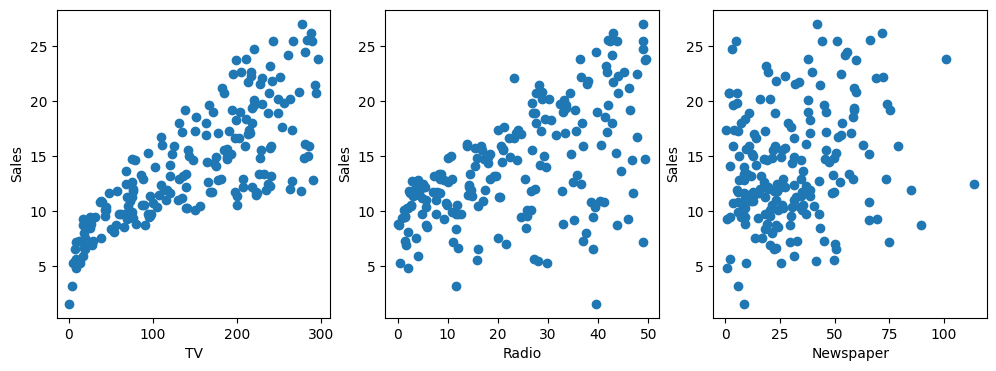

In [45]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].scatter(df['TV'], df['Sales'])
ax[0].set_xlabel("TV")
ax[0].set_ylabel("Sales")

ax[1].scatter(df['Radio'], df['Sales'])
ax[1].set_xlabel("Radio")
ax[1].set_ylabel("Sales")

ax[2].scatter(df['Newspaper'], df['Sales'])
ax[2].set_xlabel("Newspaper")
ax[2].set_ylabel("Sales")

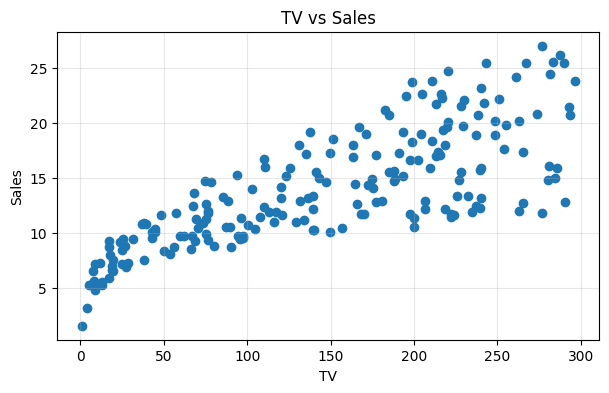

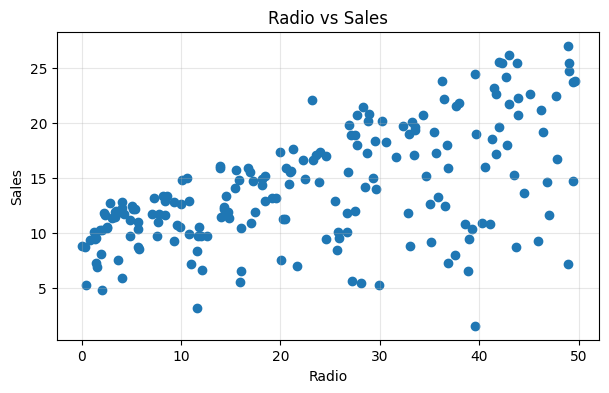

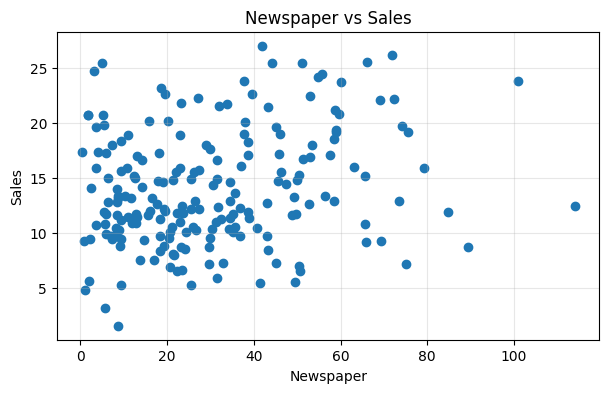

In [48]:
features = ['TV', 'Radio', 'Newspaper']

for feature in features:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[feature], df['Sales'])
    plt.xlabel(feature)
    plt.ylabel('Sales')
    plt.title(f'{feature} vs Sales')
    plt.grid(alpha=0.3)
    plt.show()

## 5. Prepare Features and Target

In [49]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (200, 3)
y shape: (200,)


## 6. Train-Test Split

In [53]:
import math

In [54]:
math.floor(X.shape[0] * 0.2)

40

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 160
Testing samples: 40


## 7. Train Multiple Linear Regression Model

In [56]:
model = LinearRegression()
model.fit(X_train, y_train)     ## (m, features)  (1, 3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
model.coef_

array([0.04492202, 0.18720502, 0.00541582])

In [58]:
model.intercept_

2.9338020306193204

In [59]:
X.columns

Index(['TV', 'Radio', 'Newspaper'], dtype='object')

In [60]:
d = {
    'Feature': X.columns,
    'Coefficient': model.coef_
}

In [61]:
print('Intercept:', model.intercept_)

coefficients = pd.DataFrame(d)
coefficients

Intercept: 2.9338020306193204


,Feature,Coefficient
0,TV,0.044922
1,Radio,0.187205
2,Newspaper,0.005416


## 8. Model Evaluation

In [62]:
X_test.shape

(40, 3)

In [63]:
y_pred = model.predict(X_test)

In [67]:
X_test.head()

,TV,Radio,Newspaper
95,163.3,31.6,52.9
15,195.4,47.7,52.9
30,292.9,28.3,43.2
158,11.7,36.9,45.2
128,220.3,49.0,3.2


In [65]:
y_pred

array([16.47174398, 20.92774181, 21.62332819, 10.61205007, 22.02050055,
       13.14503544, 21.03850749,  7.45113253, 13.63190432, 15.18235963,
        8.96600415,  6.68633818, 14.56377498,  8.82471986,  9.7376156 ,
       12.23036639,  8.74640885, 16.24917551, 10.29270647, 18.80600252,
       19.69198238, 13.44862238, 12.24964961, 21.42928472,  7.7793026 ,
        5.82743884, 20.75752469, 11.96115407,  9.20029144,  8.41449689,
       12.5107707 ,  9.97921851, 21.44166975, 12.35801793, 18.34594909,
       20.08406414, 13.94820633, 20.96250936, 10.97982243,  4.58079315])

In [64]:
y_test

95     16.9
15     22.4
30     21.4
158     7.3
128    24.7
115    12.6
69     22.3
170     8.4
174    11.5
45     14.9
66      9.5
182     8.7
165    11.9
78      5.3
186    10.3
177    11.7
56      5.5
152    16.6
82     11.3
68     18.9
124    19.7
16     12.5
148    10.9
93     22.2
65      9.3
60      8.1
84     21.7
67     13.4
125    10.6
132     5.7
9      10.6
18     11.3
55     23.7
75      8.7
150    16.1
104    20.7
135    11.6
137    20.8
164    11.9
76      6.9
Name: Sales, dtype: float64

In [68]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

R² Score: 0.8984
Mean Absolute Error: 1.4735
Mean Squared Error: 3.2063


## 9. Actual vs Predicted Sales

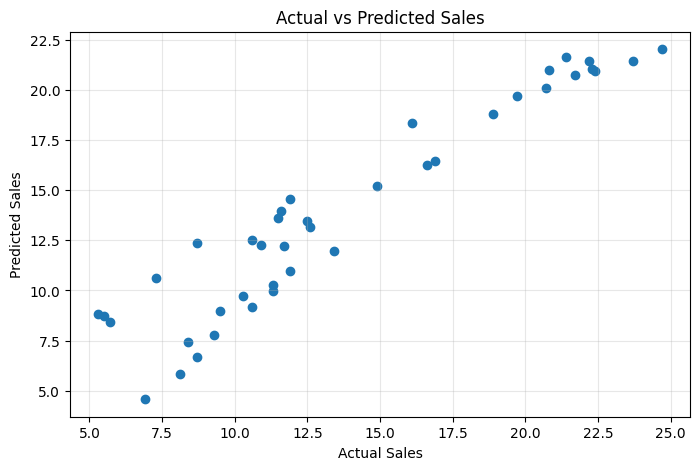

In [69]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.grid(alpha=0.3)
plt.show()

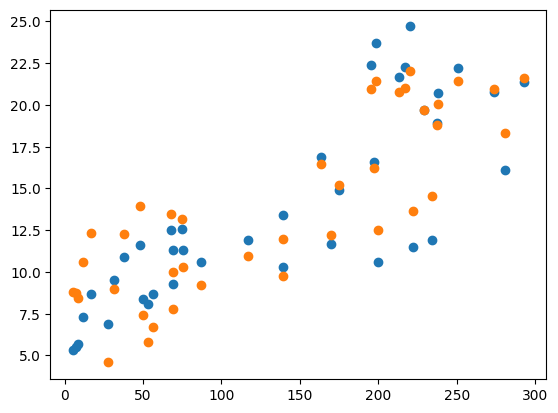

In [72]:
plt.scatter(X_test['TV'], y_test)
plt.scatter(X_test['TV'], y_pred)

## 10. Residual Plot

- Residual = Actual − Predicted

In [79]:
y_test.iloc[0]

16.9

In [78]:
y_test.iloc[0] - y_pred[0]

0.4282560171874792

In [77]:
y_pred[0]

16.47174398281252

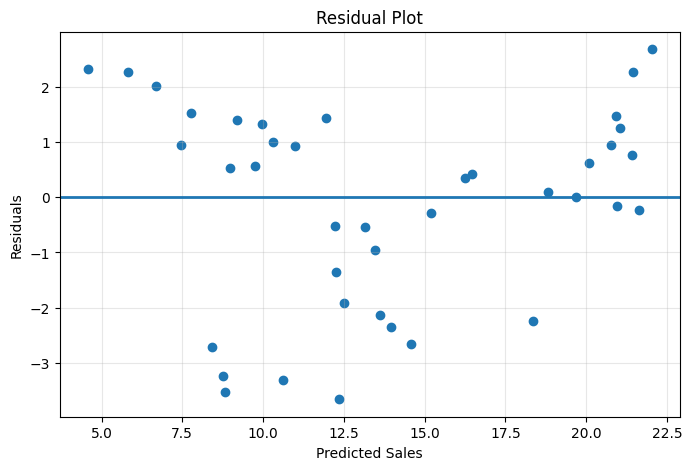

In [81]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linewidth=2)
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(alpha=0.3)
plt.show()

## 11. Save the Trained Model

In [82]:
model_path = 'advertising_multiple_linear_regression.joblib'
joblib.dump(model, model_path)


print(f'Model saved to: {model_path}')

Model saved to: advertising_multiple_linear_regression.joblib


## 12. Load Model and Make a Prediction

In [83]:
loaded_model = joblib.load('advertising_multiple_linear_regression.joblib')

# Example: TV=150, Radio=25, Newspaper=30
new_data = pd.DataFrame({
    'TV': [150],
    'Radio': [25],
    'Newspaper': [30]
})


In [85]:
pred = loaded_model.predict(new_data)

pred[0]

14.514705674583029

In [86]:
predicted_sales = loaded_model.predict(new_data)[0]
print(f'Predicted Sales: {predicted_sales:.2f}')

Predicted Sales: 14.51
